<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/PLN/ProyectoPLN_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autor: Juan Francisco Gámez Cortés.
Matricula: 261554 Mayo de 2026

Materia: Procesamiento de Lenguaje Natural

Proyecto final: Predicción de síntomas médicos

En este proyecto desarrollarán un sistema para la predicción de síntomas médicos a partir de datos textuales recogidos de registros o transcripciones médicas. El objetivo es aplicar técnicas de PLN para preprocesar, representar, modelar y evaluar el texto con foco en aplicaciones de salud.

El dataset contiene ejemplos de diferentes síntomas médicos descritos en formato textual con el objetivo de construir modelos que puedan identificar el síntoma presente en una entrada dada. Cada muestra pertenece a una de varias clases que representan síntomas o condiciones comunes reportadas por pacientes.

Descripción
-----------
Este script implementa un flujo completo para:
1) Cargar y explorar un dataset con columnas: `phrase` (texto) y `prompt` (clase).
2) Preprocesar y normalizar el texto (y limpiar/normalizar la columna `prompt`).
3) Generar representaciones vectoriales usando embeddings contextuales (Transformers).
4) Entrenar y optimizar 3 modelos distintos (LR, SVM lineal, RandomForest) con GridSearchCV.
5) Ejecutar validación cruzada estratificada de 10 folds.
6) Evaluar los modelos con métricas apropiadas, comparar y seleccionar el mejor.

In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
!pip install transformers torch

In [2]:
import os
import re
import time
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# NLTK para preprocesamiento
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Transformers para Embeddings
import torch
from transformers import AutoTokenizer, AutoModel


In [4]:
# --- Parámetros Generales ---
def set_global_seed(seed: int = 42) -> None:
    """Fija semillas para reproducibilidad (Python, NumPy, PyTorch)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def ensure_nltk_resources() -> None:
    """Descarga recursos NLTK necesarios si no existen."""
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)

@dataclass
class TextPreprocessConfig:
    """Configuración del preprocesamiento."""
    language: str = "english"
    keep_negations: bool = True

set_global_seed(42)
ensure_nltk_resources()

## Carga de Datos y Análisis Exploratorio (EDA)


================ ANÁLISIS EXPLORATORIO DE DATOS (EDA) ================

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6661 entries, 0 to 6660
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   phrase  6661 non-null   object
 1   prompt  6661 non-null   object
dtypes: object(2)
memory usage: 104.2+ KB
None

--- Primeras 5 filas ---
                                              phrase            prompt
0                    When I remember her I feel down    Emotional pain
1  When I carry heavy things I feel like breaking...  Hair falling out
2          there is too much pain when i move my arm       Heart hurts
3  My son had his lip pierced and it is swollen a...    Infected wound
4             My muscles in my lower back are aching    Infected wound

--- Valores Nulos ---
phrase    0
prompt    0
dtype: int64

--- Filas Duplicadas ---
Total de duplicados: 5954

Distribución de Clases de 

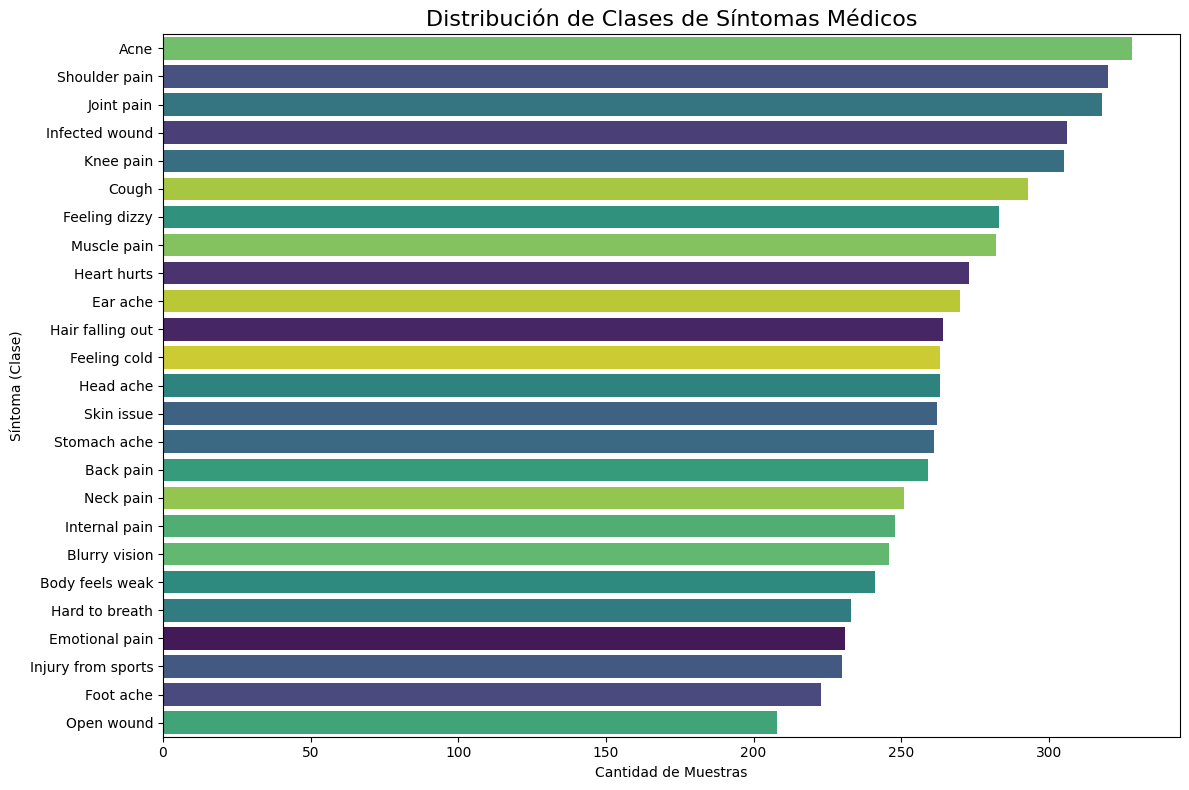


---Conteo por Clase ---
prompt
Acne                  328
Shoulder pain         320
Joint pain            318
Infected wound        306
Knee pain             305
Cough                 293
Feeling dizzy         283
Muscle pain           282
Heart hurts           273
Ear ache              270
Hair falling out      264
Feeling cold          263
Head ache             263
Skin issue            262
Stomach ache          261
Back pain             259
Neck pain             251
Internal pain         248
Blurry vision         246
Body feels weak       241
Hard to breath        233
Emotional pain        231
Injury from sports    230
Foot ache             223
Open wound            208
Name: count, dtype: int64

Histogramas de cantidad de palabras y caracteres



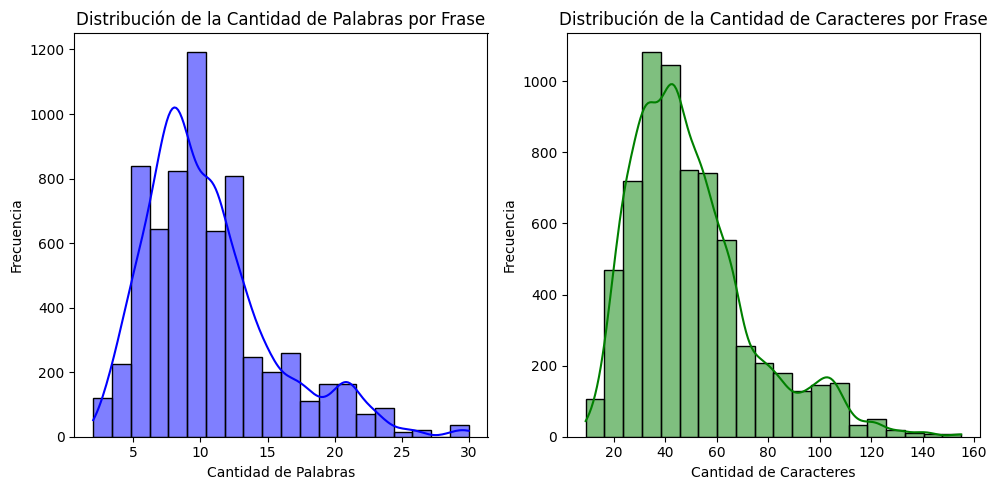


Longitud por clase (palabras)



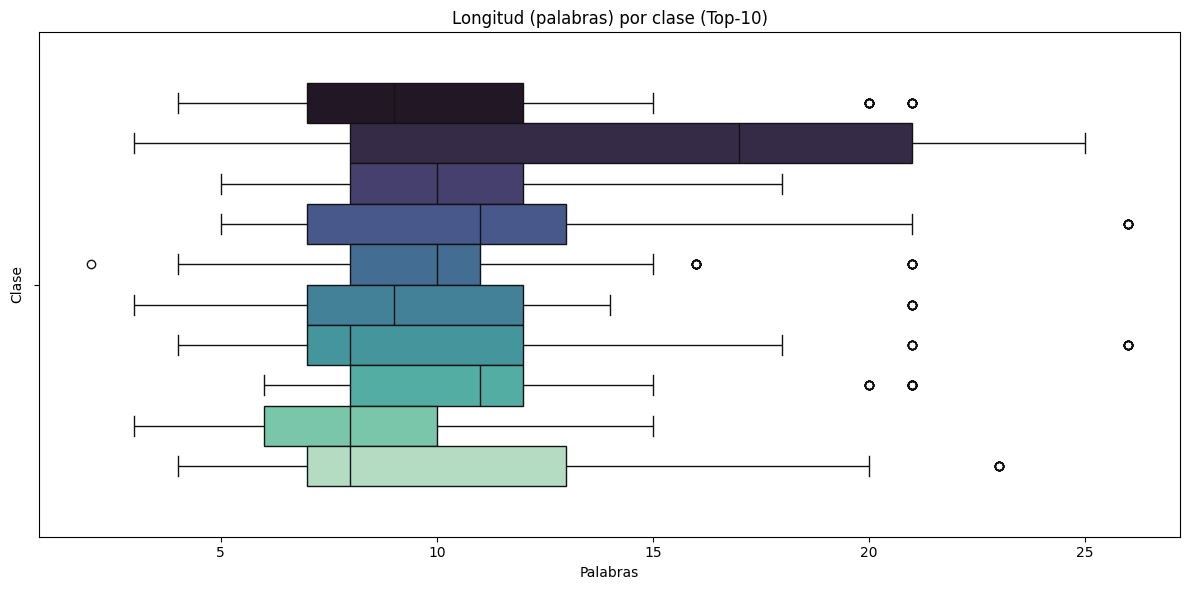


Longitud por clase (caracteres)



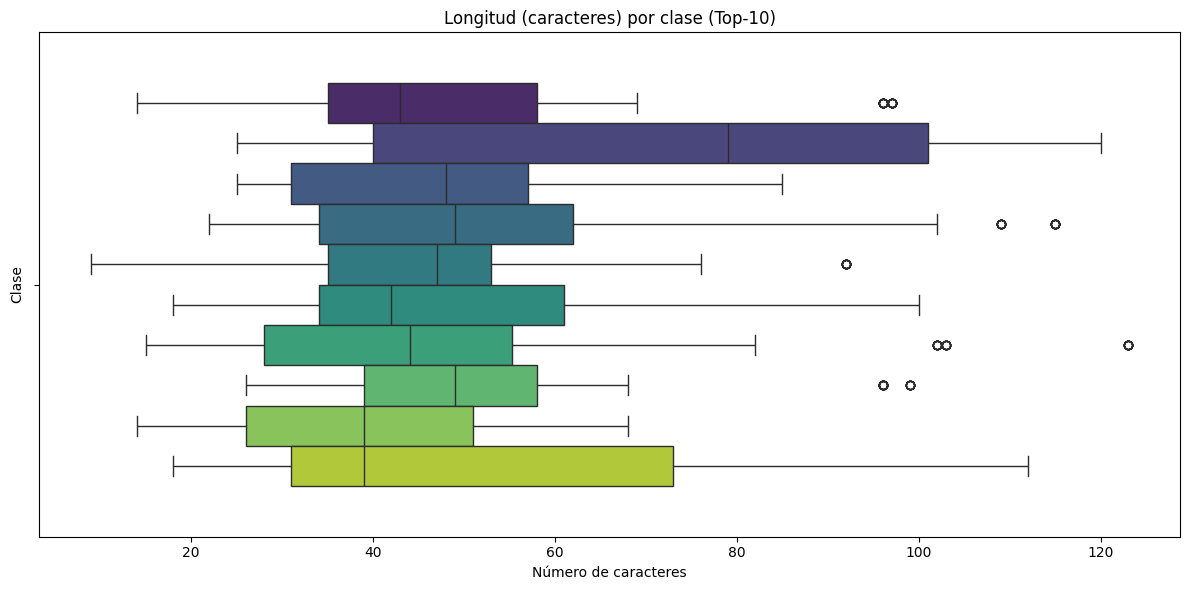


--- Estadísticas Descriptivas de Longitud del Texto ---
        word_count   char_count
count  6661.000000  6661.000000
mean     10.543462    50.026122
std       4.807787    23.672184
min       2.000000     9.000000
25%       7.000000    33.000000
50%      10.000000    45.000000
75%      13.000000    61.000000
max      30.000000   155.000000

Nube de palabras



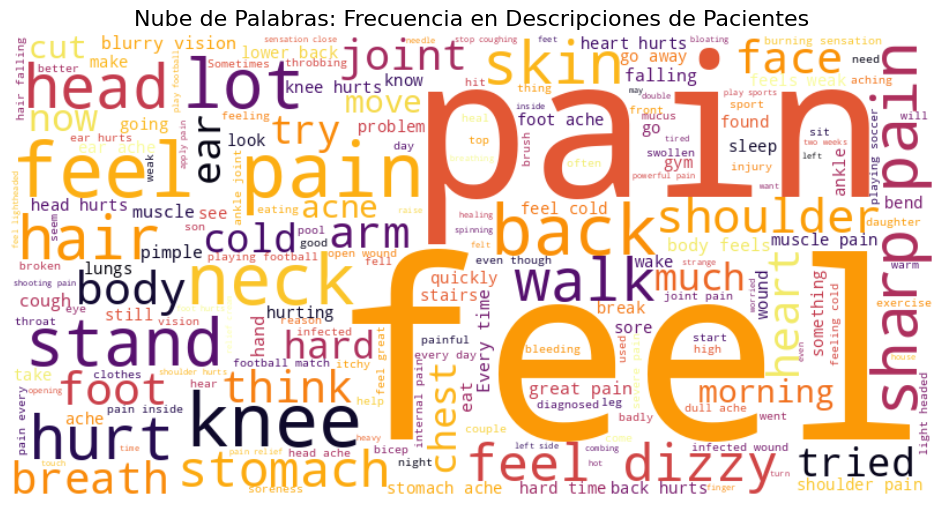


Nube de palabras por clase (Top-3)



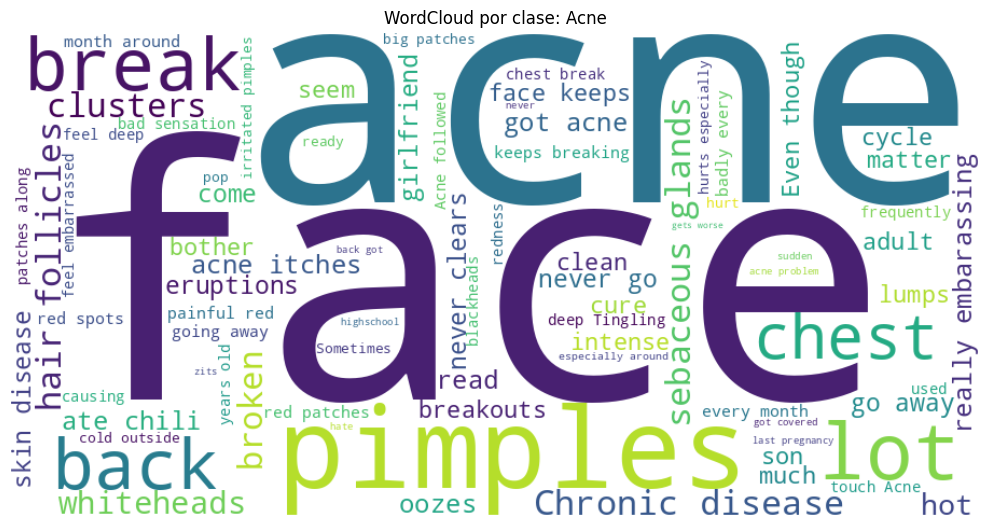

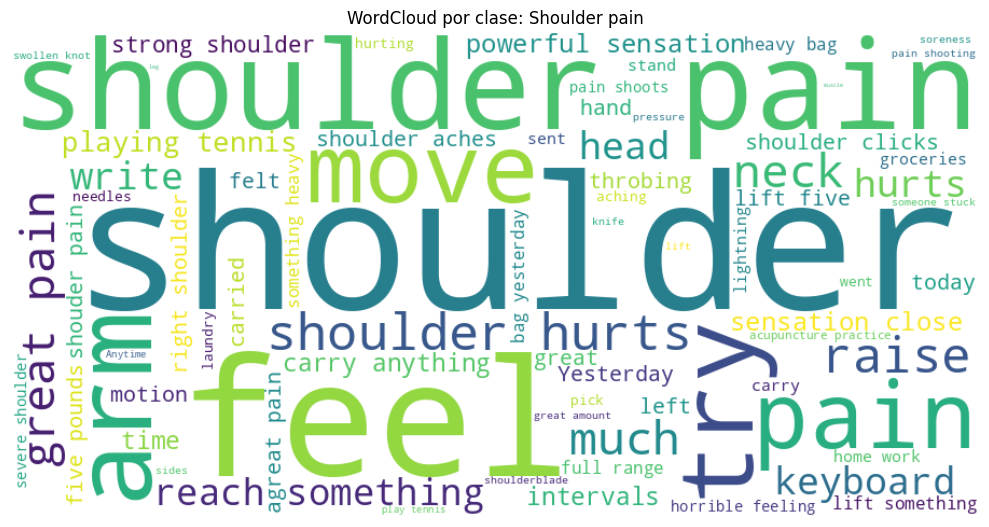

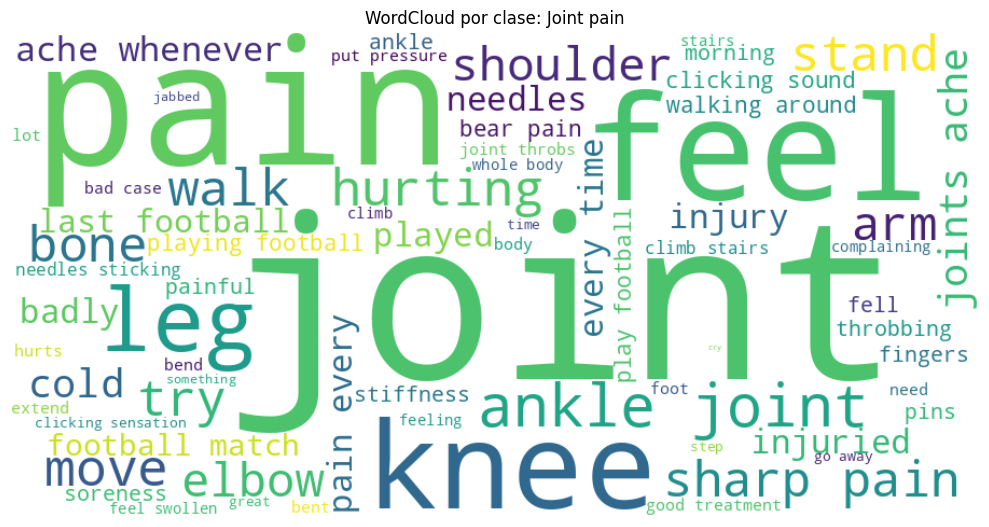

In [11]:
# --- Carga de Datos ---
DATA_PATH = "/content/drive/MyDrive/PLN/ProyectoFinal/Dataset.csv"
df = pd.read_csv(DATA_PATH)

def run_eda(df: pd.DataFrame, out_dir: str = "./salidas") -> None:
    """Realiza EDA completo + visualizaciones."""
    print("================ ANÁLISIS EXPLORATORIO DE DATOS (EDA) ================\n")

    # Inspección inicial
    print("--- Información General del Dataset ---")
    print(df.info())
    print("\n--- Primeras 5 filas ---")
    print(df.head())

    # Verificación de valores nulos o duplicados
    print("\n--- Valores Nulos ---")
    print(df.isnull().sum())
    print("\n--- Filas Duplicadas ---")
    print(f"Total de duplicados: {df.duplicated().sum()}")

    # 2. Distribución de las Clases (Síntomas)
    print('\nDistribución de Clases de Síntomas Médicos\n')
    plt.figure(figsize=(12, 8))
    sns.countplot(y='prompt', data=df, order=df['prompt'].value_counts().index, hue='prompt', palette='viridis', legend=False)
    plt.title('Distribución de Clases de Síntomas Médicos', fontsize=16)
    plt.xlabel('Cantidad de Muestras')
    plt.ylabel('Síntoma (Clase)')
    plt.tight_layout()
    plt.show()

    print("\n---Conteo por Clase ---")
    print(df['prompt'].value_counts())

    # 3. Análisis de Longitud del Texto
    # qué tan largos son los textos (phrase)
    df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))
    df['char_count'] = df['phrase'].apply(lambda x: len(str(x)))

    plt.figure(figsize=(10, 5))

    # Histograma de cantidad de palabras
    print('\nHistogramas de cantidad de palabras y caracteres\n')
    plt.subplot(1, 2, 1)
    sns.histplot(df['word_count'], bins=20, kde=True, color='blue')
    plt.title('Distribución de la Cantidad de Palabras por Frase')
    plt.xlabel('Cantidad de Palabras')
    plt.ylabel('Frecuencia')

    # Histograma de cantidad de caracteres
    plt.subplot(1, 2, 2)
    sns.histplot(df['char_count'], bins=20, kde=True, color='green')
    plt.title('Distribución de la Cantidad de Caracteres por Frase')
    plt.xlabel('Cantidad de Caracteres')
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

    # Longitud por clase (palabras)
    print('\nLongitud por clase (palabras)\n')
    plt.figure(figsize=(12, 6))
    top_classes = df["prompt"].value_counts().head(10).index
    sns.boxplot(data=df[df["prompt"].isin(top_classes)], x="word_count",hue='prompt', palette="mako", legend=False)
    plt.title("Longitud (palabras) por clase (Top-10)")
    plt.xlabel("Palabras")
    plt.ylabel("Clase")
    plt.tight_layout()
    plt.show()

    # Longitud por clase (caracteres)
    print('\nLongitud por clase (caracteres)\n')
    plt.figure(figsize=(12, 6))
    top_classes = df["prompt"].value_counts().head(10).index
    sns.boxplot(data=df[df["prompt"].isin(top_classes)], x="char_count", hue="prompt", palette="viridis", legend=False)
    plt.title("Longitud (caracteres) por clase (Top-10)")
    plt.xlabel("Número de caracteres")
    plt.ylabel("Clase")

    plt.tight_layout()
    plt.show()

    print("\n--- Estadísticas Descriptivas de Longitud del Texto ---")
    print(df[['word_count', 'char_count']].describe())

    # 4. Análisis de Frecuencia de Palabras - Nube de Palabras
    print('\nNube de palabras\n')
    text_all = " ".join(phrase for phrase in df['phrase'].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(text_all)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title('Nube de Palabras: Frecuencia en Descripciones de Pacientes', fontsize=16)
    plt.show()

    # WordCloud por clase (Top-3)
    print('\nNube de palabras por clase (Top-3)\n')
    for cls in df["prompt"].value_counts().head(3).index:
      text_cls = " ".join(df.loc[df["prompt"] == cls, "phrase"].astype(str).tolist())
      wc_cls = WordCloud(width=900, height=450, background_color="white", colormap="viridis").generate(text_cls)
      plt.figure(figsize=(10, 8))
      plt.imshow(wc_cls, interpolation="bilinear")
      plt.axis("off")
      plt.title(f"WordCloud por clase: {cls}")
      plt.tight_layout()
      plt.show()

# Ejecutar el EDA
run_eda(df)

## Preprocesamiento y Normalización


In [13]:
lemmatizer = WordNetLemmatizer()
cfg = TextPreprocessConfig()
stop_words = set(stopwords.words(cfg.language))

if cfg.keep_negations:
    negations = {"no", "not", "nor", "none", "neither", "never", "without"}
    stop_words = stop_words - negations

def normalize_prompt_value(x: str) -> str:
    """Normaliza etiquetas/clases en la columna prompt."""
    return str(x).strip().capitalize()

def preprocess_text(text: str, lemmatizer: WordNetLemmatizer, stop_words: set, cfg: TextPreprocessConfig) -> str:
    """Normaliza y limpia el texto clínico de phrase."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Solo letras

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)

# Aplicar normalización
df['prompt_norm'] = df['prompt'].apply(normalize_prompt_value)
df['clean_phrase'] = df['phrase'].apply(lambda x: preprocess_text(x, lemmatizer, stop_words, cfg))

# Codificar Etiquetas
label_encoder = LabelEncoder()
df['encoded_prompt'] = label_encoder.fit_transform(df['prompt_norm'])
clases_sintomas = label_encoder.classes_

print("--- Ejemplos de Texto Preprocesado ---")
print(df[['phrase', 'clean_phrase', 'prompt_norm']].head(10))

--- Ejemplos de Texto Preprocesado ---
                                              phrase  \
0                    When I remember her I feel down   
1  When I carry heavy things I feel like breaking...   
2          there is too much pain when i move my arm   
3  My son had his lip pierced and it is swollen a...   
4             My muscles in my lower back are aching   
5  i have muscle pain that my back\nI Have Muscle...   
6                  I have muscle pain in my left leg   
7  I have cut my finger because of playing footba...   
8  I have acne in my face and other problems in m...   
9                    I have a strange rash on my arm   

                                        clean_phrase         prompt_norm  
0                                      remember feel      Emotional pain  
1          carry heavy thing feel like breaking back    Hair falling out  
2                                 much pain move arm         Heart hurts  
3  son lip pierced swollen skin inside lip g

## Generar representaciones vectoriales embeddings

In [16]:
# 1. Configuración del dispositivo (Verificar que la GPU de Colab esté activa)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")

# 2. Cargar el tokenizador y el modelo pre-entrenado
# Modelo "distilbert-base-uncased"
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# 3. Función para extraer embeddings por lotes
def extraer_embeddings_batch(textos, batch_size=32):
    todos_embeddings = []

    # Procesar en bloques
    for i in range(0, len(textos), batch_size):
        batch = textos[i:i+batch_size]

        # Tokenización adaptada al modelo BERT
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=64, return_tensors="pt").to(device)

        # Pasamos el texto por el modelo sin calcular gradientes
        with torch.no_grad():
            outputs = model(**inputs)

        # Extraemos el token que contiene el resumen contextual de toda la frase
        embeddings_cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        todos_embeddings.extend(embeddings_cls)

    return np.array(todos_embeddings)

# 4. Generación de las representaciones vectoriales
textos = df['clean_phrase'].tolist()

print("Generando embeddings contextuales...")
X_embeddings = extraer_embeddings_batch(textos)
y_target = df['encoded_prompt'].values

print(f"Dimensiones de la matriz de características (X): {X_embeddings.shape}")

Dispositivo activo: cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings contextuales...
Dimensiones de la matriz de características (X): (6661, 768)


## Entrenar y optimizar 3 modelos distintos (LR, SVM lineal, RandomForest) con GridSearchCV.

## Ejecutar validación cruzada estratificada de 10 folds.



--- Iniciando Entrenamiento y Optimización ---

  Optimizando: LogisticRegression...
  LogisticRegression -> Mejor F1-Macro CV: 0.9973
  Parámetros: {'C': 10, 'solver': 'lbfgs'}
  Tiempo: 357.51 s

  Optimizando: LinearSVC...
  LinearSVC -> Mejor F1-Macro CV: 0.9973
  Parámetros: {'C': 1}
  Tiempo: 938.80 s

  Optimizando: RandomForest...
  RandomForest -> Mejor F1-Macro CV: 0.9974
  Parámetros: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
  Tiempo: 3048.83 s

================ EVALUACIÓN FINAL EN TEST ================

  EVALUACIÓN EN TEST: LogisticRegression
  accuracy: 0.9955
  f1_macro: 0.9953
  precision_macro: 0.9958
  recall_macro: 0.9952

--- Reporte de clasificación: LogisticRegression ---
                    precision    recall  f1-score   support

              Acne       1.00      1.00      1.00        66
         Back pain       1.00      1.00      1.00        52
     Blurry vision       1.00      1.00      1.00        49
   Body fee

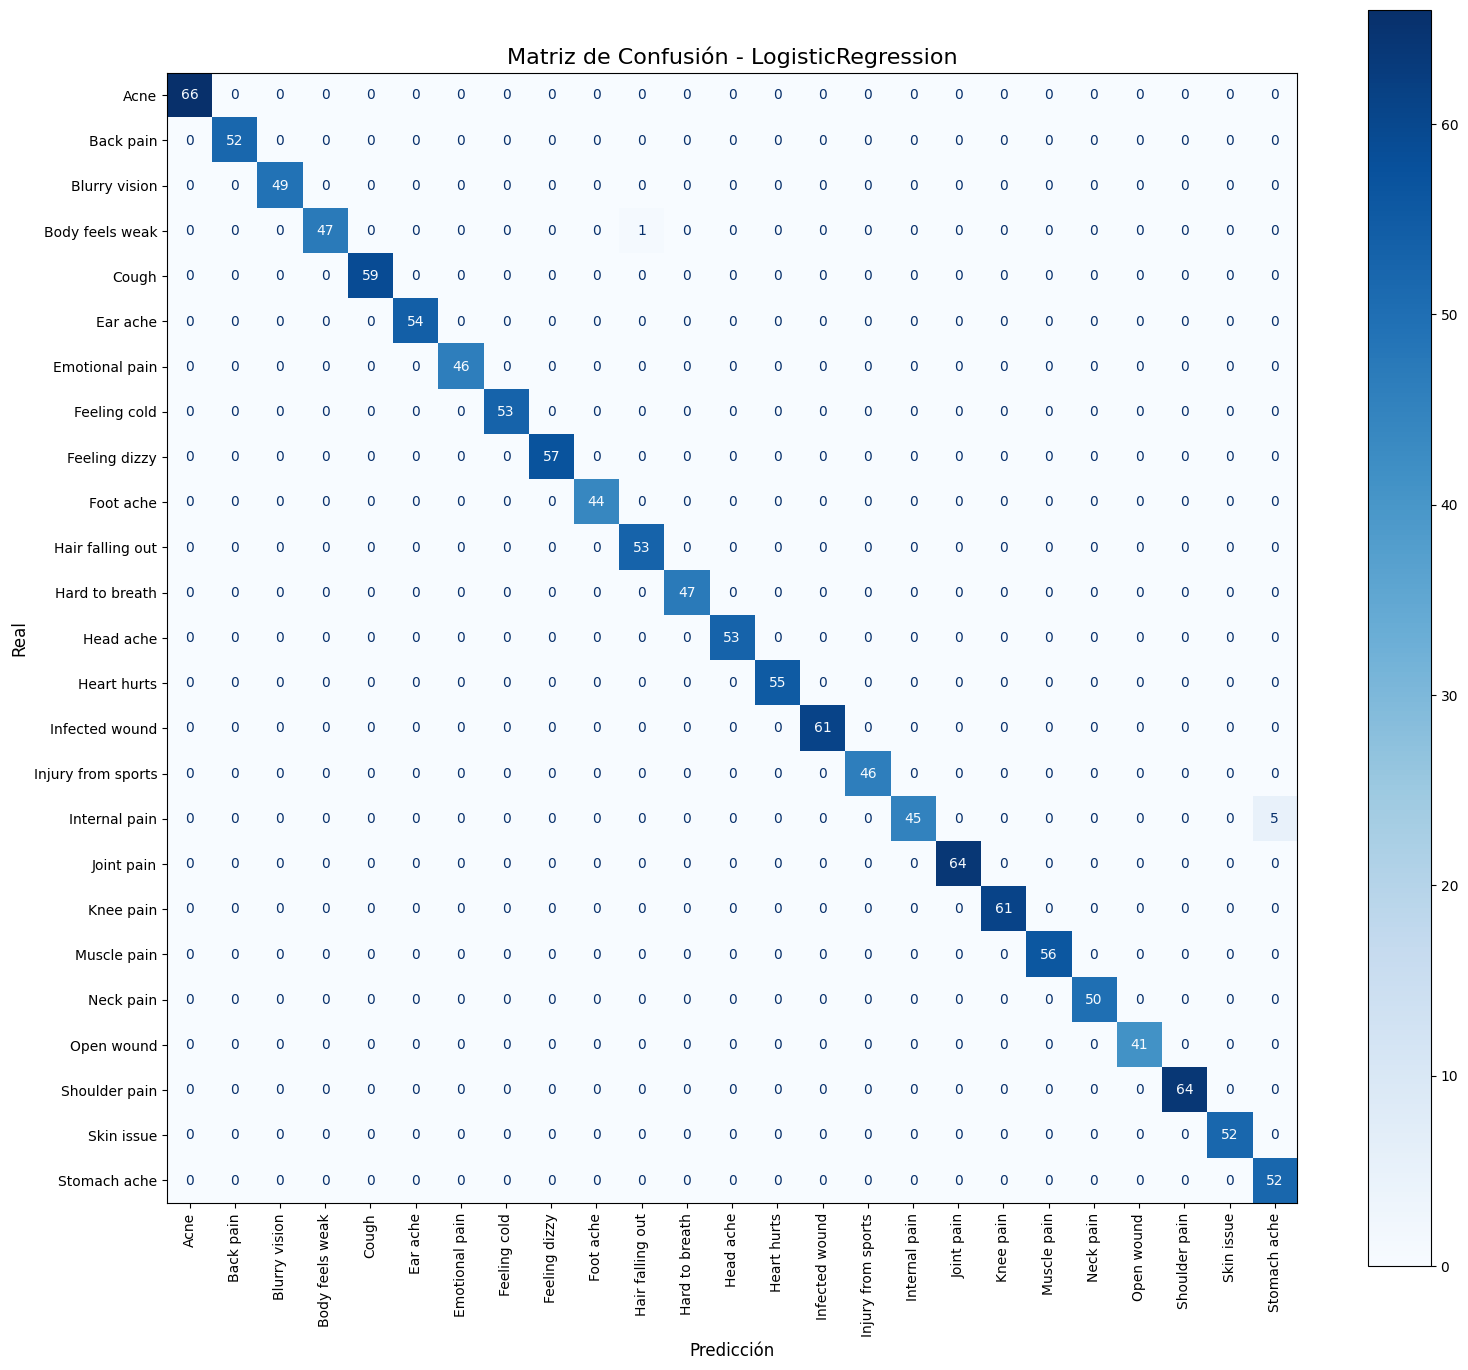


  EVALUACIÓN EN TEST: LinearSVC
  accuracy: 0.9955
  f1_macro: 0.9953
  precision_macro: 0.9958
  recall_macro: 0.9952

--- Reporte de clasificación: LinearSVC ---
                    precision    recall  f1-score   support

              Acne       1.00      1.00      1.00        66
         Back pain       1.00      1.00      1.00        52
     Blurry vision       1.00      1.00      1.00        49
   Body feels weak       1.00      0.98      0.99        48
             Cough       1.00      1.00      1.00        59
          Ear ache       1.00      1.00      1.00        54
    Emotional pain       1.00      1.00      1.00        46
      Feeling cold       1.00      1.00      1.00        53
     Feeling dizzy       1.00      1.00      1.00        57
         Foot ache       1.00      1.00      1.00        44
  Hair falling out       0.98      1.00      0.99        53
    Hard to breath       1.00      1.00      1.00        47
         Head ache       1.00      1.00      1.00     

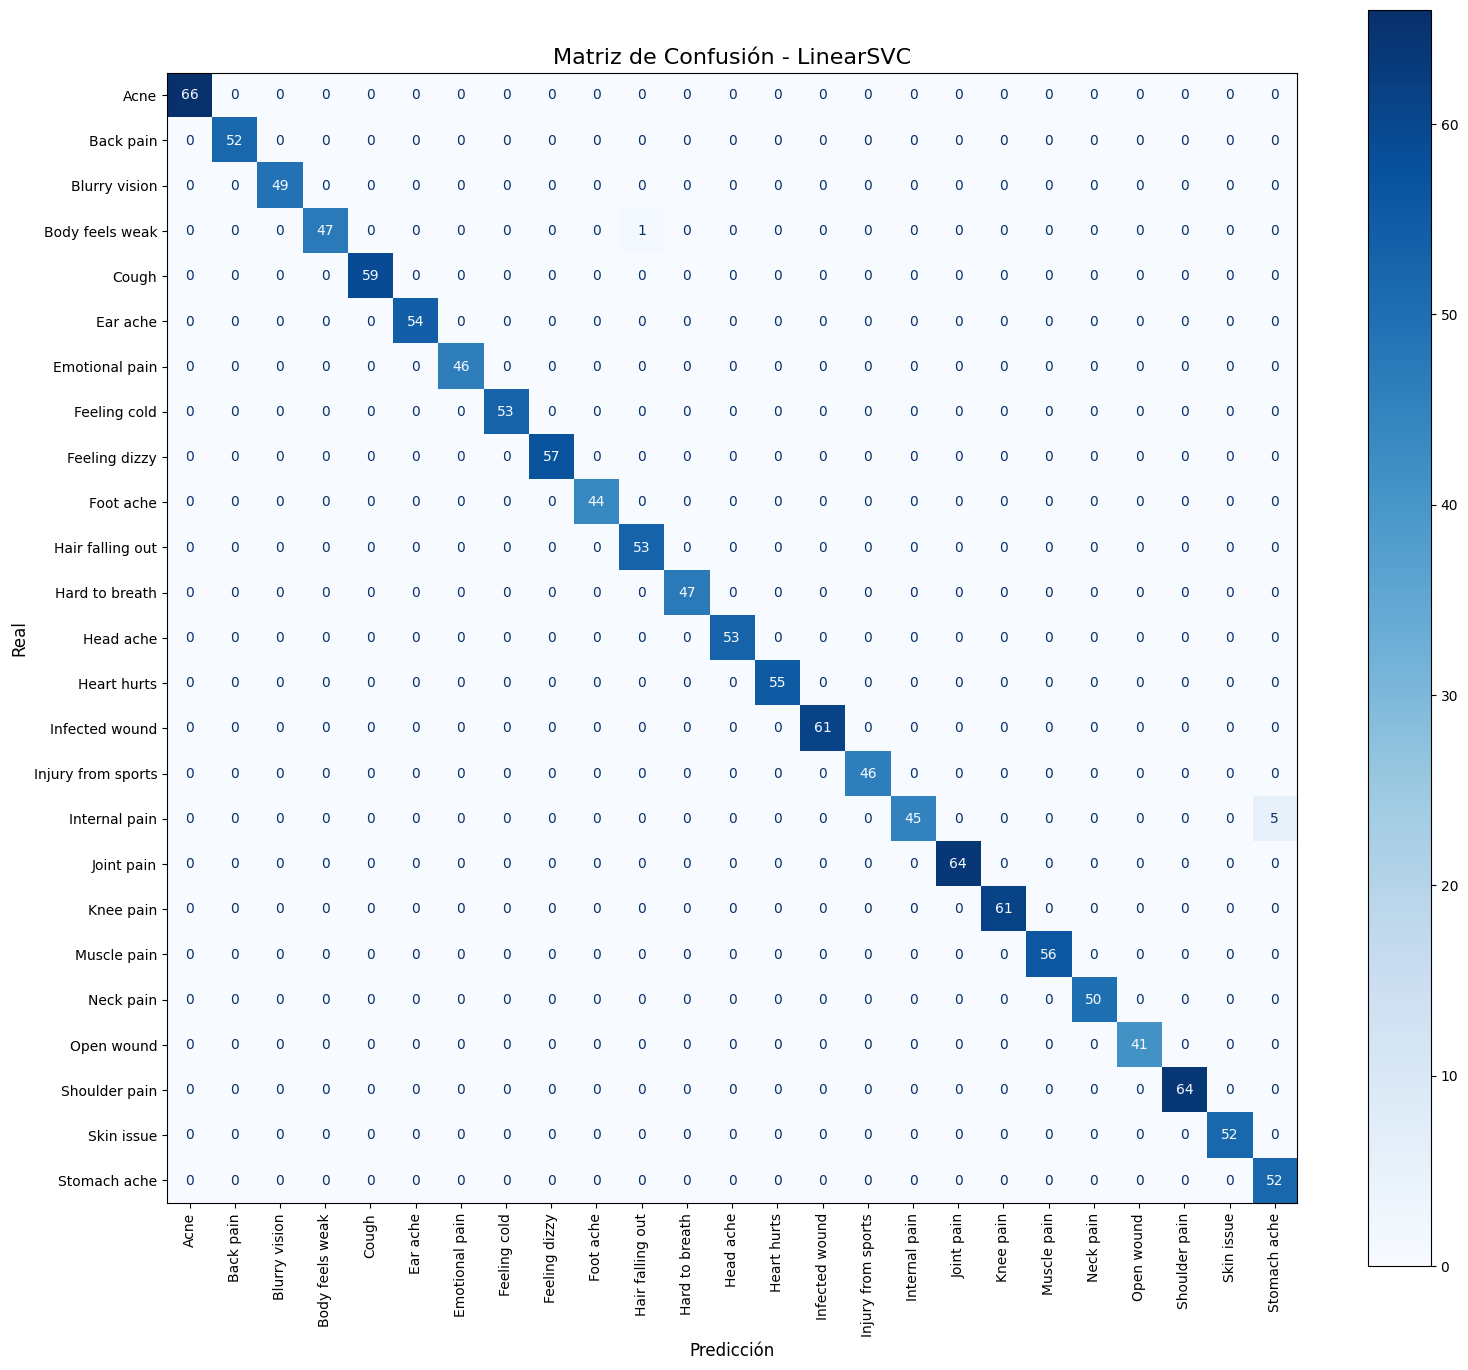


  EVALUACIÓN EN TEST: RandomForest
  accuracy: 0.9955
  f1_macro: 0.9953
  precision_macro: 0.9958
  recall_macro: 0.9952

--- Reporte de clasificación: RandomForest ---
                    precision    recall  f1-score   support

              Acne       1.00      1.00      1.00        66
         Back pain       1.00      1.00      1.00        52
     Blurry vision       1.00      1.00      1.00        49
   Body feels weak       1.00      0.98      0.99        48
             Cough       1.00      1.00      1.00        59
          Ear ache       1.00      1.00      1.00        54
    Emotional pain       1.00      1.00      1.00        46
      Feeling cold       1.00      1.00      1.00        53
     Feeling dizzy       1.00      1.00      1.00        57
         Foot ache       1.00      1.00      1.00        44
  Hair falling out       0.98      1.00      0.99        53
    Hard to breath       1.00      1.00      1.00        47
         Head ache       1.00      1.00      1.0

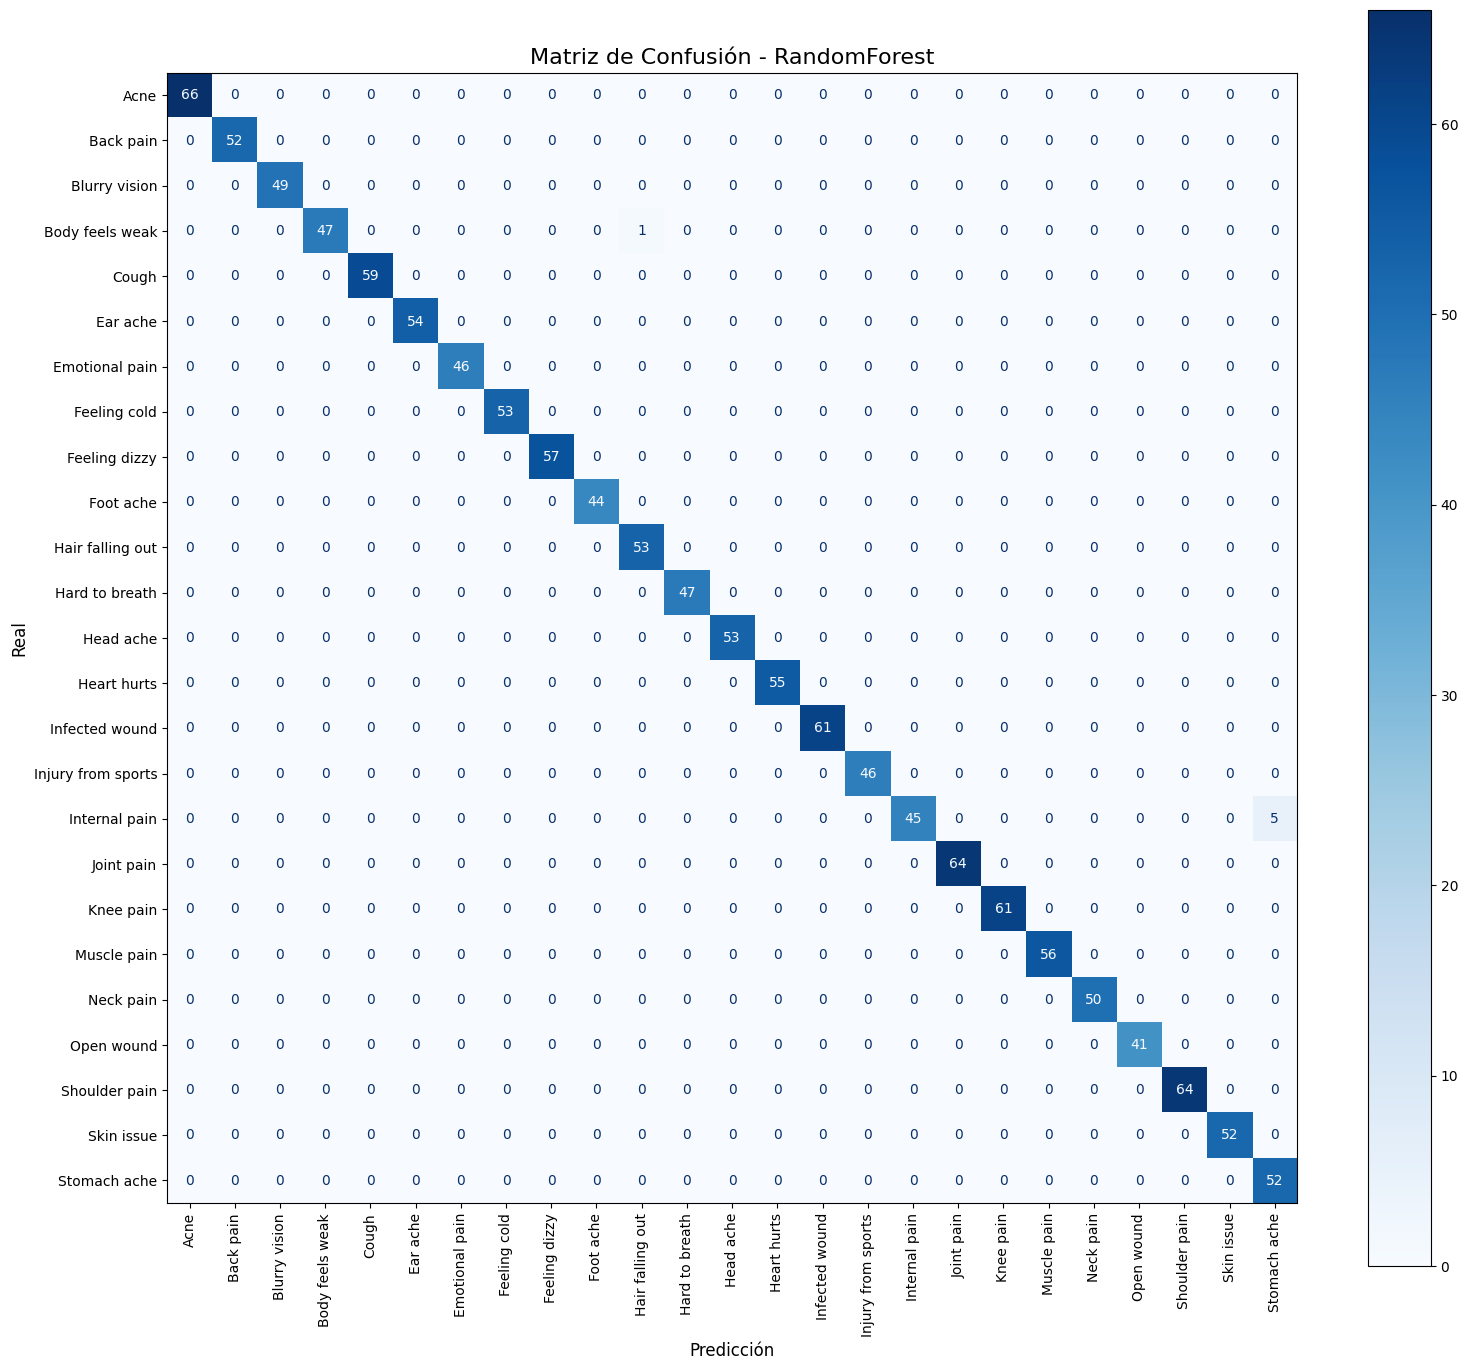

In [19]:
# 1. Partición de Datos
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y_target,
    test_size=0.2, random_state=42, stratify=y_target
)

# 2. Definición de Modelos y Grids de Hiperparámetros
def build_models_and_grids(seed: int = 42):
    """Define 3 modelos y sus grids de hiperparámetros."""

    modelos = {
        'LogisticRegression': LogisticRegression(
            max_iter=3000, random_state=seed
        ),
        'LinearSVC': LinearSVC(
            max_iter=5000, dual=False, random_state=seed
        ),
        'RandomForest': RandomForestClassifier(
            random_state=seed
        )
    }

    grids = {
        'LogisticRegression': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs'],
        },
        'LinearSVC': {
            'C': [0.01, 0.1, 1, 10],
        },
        'RandomForest': {
            'n_estimators': [100, 200],
            'max_depth': [None, 20, 40],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
        }
    }

    return modelos, grids


modelos, grids = build_models_and_grids(seed=42)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
mejores_modelos = {}

# 3. Entrenamiento con GridSearchCV + Validación Cruzada 10 folds
print("--- Iniciando Entrenamiento y Optimización ---")

for nombre, modelo in modelos.items():
    print(f"\n  Optimizando: {nombre}...")
    inicio = time.time()

    grid = GridSearchCV(
        estimator=modelo,
        param_grid=grids[nombre],
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    mejores_modelos[nombre] = grid.best_estimator_
    dt = time.time() - inicio

    print(f"  {nombre} -> Mejor F1-Macro CV: {grid.best_score_:.4f}")
    print(f"  Parámetros: {grid.best_params_}")
    print(f"  Tiempo: {dt:.2f} s")


# 4. Función de evaluación en Test
def evaluate_on_test(model, X_test: np.ndarray, y_test: np.ndarray) -> dict:
    """Evalúa un modelo en el conjunto de prueba y devuelve métricas."""
    y_pred = model.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    }


# 5. EVALUACIÓN DE LOS 3 MODELOS EN TEST
print("\n================ EVALUACIÓN FINAL EN TEST ================")
resultados_test = []

for nombre, modelo in mejores_modelos.items():

    metricas = evaluate_on_test(modelo, X_test, y_test)
    metricas['modelo'] = nombre
    resultados_test.append(metricas)

    print(f"\n{'='*60}")
    print(f"  EVALUACIÓN EN TEST: {nombre}")
    print(f"{'='*60}")
    for metrica, valor in metricas.items():
        if metrica != 'modelo':
            print(f"  {metrica}: {valor:.4f}")

    y_pred = modelo.predict(X_test)
    print(f"\n--- Reporte de clasificación: {nombre} ---")
    print(classification_report(y_test, y_pred,
                                target_names=clases_sintomas,
                                zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=clases_sintomas)

    plt.figure(figsize=(16, 14))
    disp.plot(cmap='Blues', xticks_rotation='vertical',
              ax=plt.gca(), values_format='d')
    plt.title(f"Matriz de Confusión - {nombre}", fontsize=16)
    plt.xlabel("Predicción", fontsize=12)
    plt.ylabel("Real", fontsize=12)
    plt.tight_layout()
    plt.show()




## Evaluar los modelos con métricas apropiadas, comparar y seleccionar el mejor.

In [23]:
# 6. TABLA COMPARATIVA Y SELECCIÓN DEL MEJOR MODELO

df_resultados = pd.DataFrame(resultados_test)
cols = ['modelo', 'accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
df_resultados = df_resultados[cols].sort_values(by='f1_macro', ascending=False)

print(f"\n{'='*60}")
print("  TABLA COMPARATIVA DE MODELOS (Test set)")
print(f"{'='*60}")
print(df_resultados.to_string(index=False))

mejor_nombre = df_resultados.iloc[0]['modelo']
mejor_f1 = df_resultados.iloc[0]['f1_macro']

print(f"\n>>> Mejor modelo seleccionado: {mejor_nombre}")
print(f">>> Razón: mayor f1_macro en test = {mejor_f1:.4f}")
print(f">>> f1_macro pondera precision y recall por igual en todas")
print(f"    las clases, crítico en clasificación multiclase médica.")


  TABLA COMPARATIVA DE MODELOS (Test set)
            modelo  accuracy  f1_macro  precision_macro  recall_macro
LogisticRegression  0.995499  0.995265          0.99575      0.995167
         LinearSVC  0.995499  0.995265          0.99575      0.995167
      RandomForest  0.995499  0.995265          0.99575      0.995167

>>> Mejor modelo seleccionado: LogisticRegression
>>> Razón: mayor f1_macro en test = 0.9953
>>> f1_macro pondera precision y recall por igual en todas
    las clases, crítico en clasificación multiclase médica.


In [25]:
!jupyter nbconvert --to html /content/drive/MyDrive/Colab Notebooks/ProyectoPLN_261554.ipynb

[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Colab' matched no files
[NbConvertApp] WARNING | pattern 'Notebooks/ProyectoPLN_261554.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to a